# Most probable path according to the background

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Order params

Alpha: mean_f_free_ab_beta_ab_1_D_20_bg_Alpha
BA1: mean_f_free_ab_beta_ab_1_D_20_bg_BA1
BA2: mean_f_free_ab_beta_ab_1_D_20_bg_BA2
Delta: mean_f_free_ab_beta_ab_1_D_20_bg_Delta
WT: mean_f_free_ab_beta_ab_1_D_20_bg_WT
(21, 29)
Alpha
(21, 29)
BA1
(21, 29)
BA2
(21, 29)
Delta
(21, 29)
WT


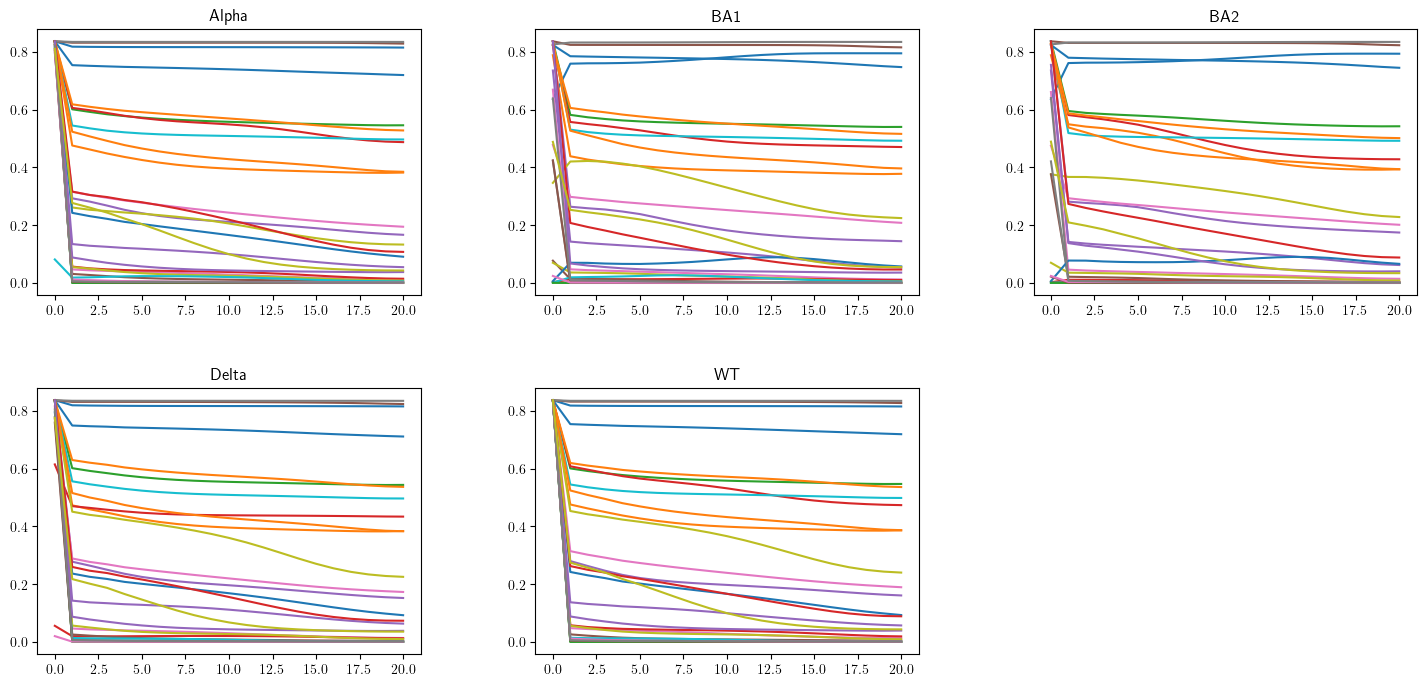

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math


dir = 'results_scripts/background/'

# Set condition sets
import os
import re

# Setup
BETA_AB = 1
D=20

# Your extract_parameters function
def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    ab_parts = path.split('_')
    condition = ab_parts[-1]
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition
    }


# Get all folders
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# Initialize lists
paths = []
labels = []

# Loop through each condition set and each condition
for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB and
        params["D"] == D 
    ):
        paths.append(d)
        labels.append(params["condition"])

# Check: paths[i] corresponds to labels[i]
for p, l in zip(paths, labels):
    print(f"{l}: {p}")


import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import math

# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Parameters
n_cols = 3
n_paths = len(labels)
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, condition in enumerate(labels):
    ax = axes[i]

    # Load and compute mutation
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy")) [:,:29]
    #we plot 29 abs vs steps. Theire names are in ab_names
    print(mopt.shape)
    binding=np.exp(178*mopt)
    print(condition)

    T = mopt.shape[0] 
    steps = np.arange(0, T )

    # Plot
    ax.plot(steps, binding, label=r"$1 - q_t \cdot L$")
    ax.set_title(f"{condition}")


# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()



In [3]:
# Your extract_parameters function
def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    ab_parts = path.split('_')
    condition = ab_parts[-1]
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition
    }

# Get all folders
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

paths = []
labels = []
SELECTED_CONDITIONS=['WT','Alpha','Delta', 'BA1']
for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB and
        params["D"] == D and
        params["condition"] in SELECTED_CONDITIONS
    ):
        paths.append(d)
        labels.append(params["condition"])

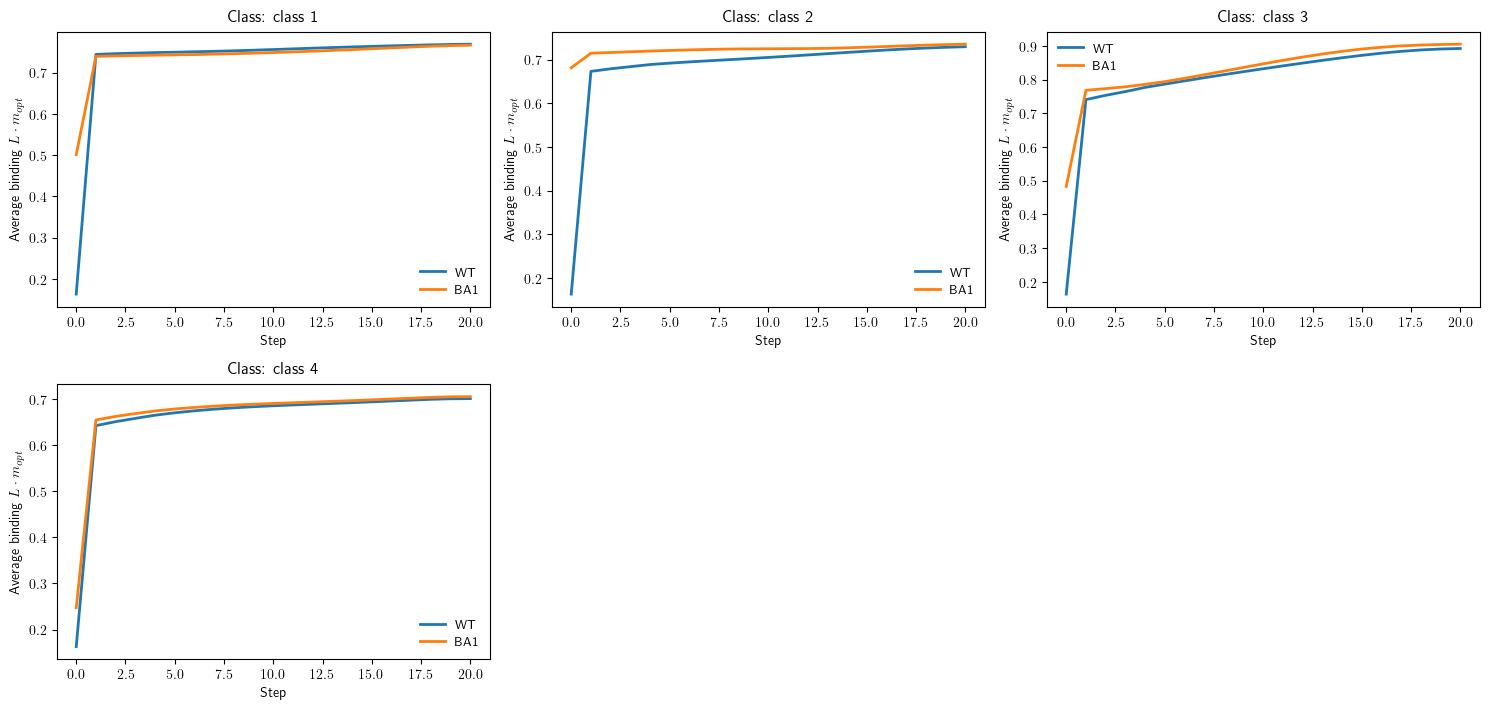

In [4]:
import pandas as pd

# --- config ---
L = 178.0
SELECTED_CONDITIONS = ["WT", "BA1"]  # already set above
dir = '../mean_field_theory/results_scripts/background/'

# Ensure ab_names exists and aligns with mopt columns
ab_names = list(ESCAPE_VECTORS.keys())

# Load antibody → class mapping
ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")
ab_to_class = dict(zip(ab_class_df['condition'].astype(str), ab_class_df['condition_subtype'].astype(str)))

# Build class -> indices over ab_names
class_to_indices = {}
for i, ab in enumerate(ab_names):
    cls = ab_to_class.get(ab, None)
    if cls is None:
        continue
    class_to_indices.setdefault(cls, []).append(i)

classes = [c for c, idxs in class_to_indices.items() if len(idxs) > 0]
classes = sorted(classes)

# Collect per-condition time series: mean(L * mopt) per class over steps
per_condition_series = {}  # condition -> {class -> 1D array over steps}
for i, condition in enumerate(labels):
    # only plot selected conditions
    if condition not in SELECTED_CONDITIONS:
        continue

    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    Lm = 1-np.exp(L * mopt)  # binding proxy

    series = {}
    for cls in classes:
        idx = class_to_indices[cls]
        cls_mean = Lm[:, idx].mean(axis=1)  # mean over antibodies in class
        series[cls] = cls_mean
    per_condition_series[condition] = series

# Plot: one subplot per antibody class, lines: WT vs BA1
n_classes = len(classes)
n_cols = 3 if n_classes >= 3 else n_classes
n_rows = int(math.ceil(n_classes / max(1, n_cols)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.6 * n_rows), squeeze=False)
axes = axes.reshape(n_rows, n_cols)

x_steps = None
for idx_cls, cls in enumerate(classes):
    r = idx_cls // n_cols
    c = idx_cls % n_cols
    ax = axes[r, c]

    for condition in SELECTED_CONDITIONS:
        if condition not in per_condition_series:
            continue
        y = per_condition_series[condition][cls]
        if x_steps is None:
            x_steps = np.arange(len(y))
        ax.plot(x_steps, y, label=condition, linewidth=2)

    ax.set_title(f"Class: {cls}", pad=8)
    ax.set_xlabel("Step")
    ax.set_ylabel(r"Average binding $L \cdot m_{opt}$")
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(False)
    ax.legend(frameon=False, fontsize=9, loc="best")

# Hide any empty subplots
for k in range(n_classes, n_rows * n_cols):
    r = k // n_cols
    c = k % n_cols
    axes[r, c].axis("off")

fig.tight_layout()


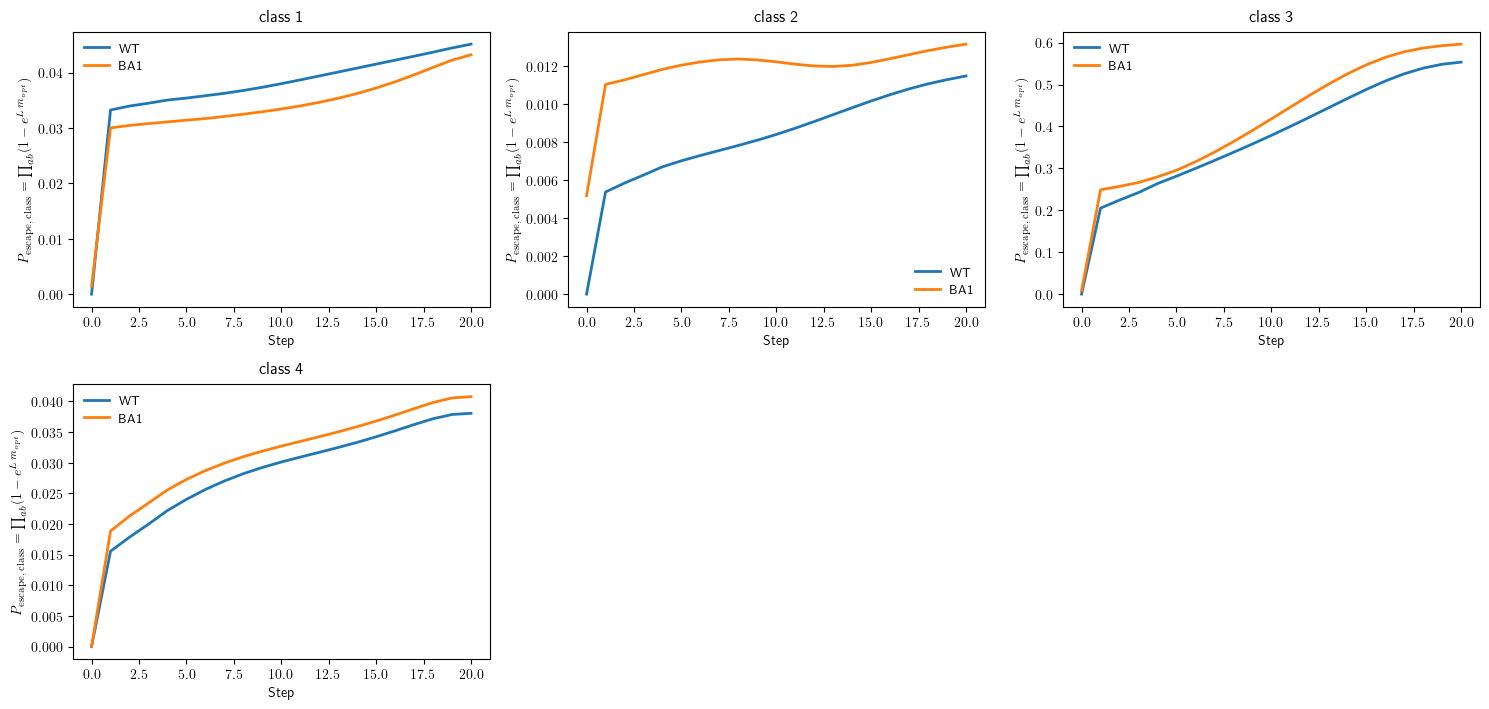

In [5]:
# --- config ---
L = 178.0  # keep consistent with your earlier code

# Build class -> indices over ab_names
class_to_indices = {}
for i, ab in enumerate(ab_names):
    cls = ab_to_class.get(ab)
    if cls is None:
        continue
    class_to_indices.setdefault(cls, []).append(i)

classes = sorted(k for k, v in class_to_indices.items() if v)

# Collect per-condition time series: P_escape_class = ∏_ab (1 - exp(L * mopt_ab))
per_condition_series = {}  # condition -> {class -> 1D array over steps}
for i, condition in enumerate(labels):
    if condition not in SELECTED_CONDITIONS:
        continue

    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    Pesc = 1.0 - np.exp(L * mopt)                           # [steps, n_abs]
    Pesc = np.clip(Pesc, 1e-12, 1.0)                        # numeric safety

    series = {}
    for cls in classes:
        idx = class_to_indices[cls]
        # product over antibodies in class, per step
        cls_prod = np.exp(np.log(Pesc[:, idx]).sum(axis=1))
        series[cls] = cls_prod
    per_condition_series[condition] = series

# Plot: one subplot per antibody class, lines: WT vs BA1
n_classes = len(classes)
n_cols = 3 if n_classes >= 3 else n_classes
n_rows = int(math.ceil(n_classes / max(1, n_cols)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.6 * n_rows), squeeze=False)
axes = axes.reshape(n_rows, n_cols)

x_steps = None
for idx_cls, cls in enumerate(classes):
    r = idx_cls // n_cols
    c = idx_cls % n_cols
    ax = axes[r, c]

    for condition in SELECTED_CONDITIONS:
        if condition not in per_condition_series:
            continue
        y = per_condition_series[condition][cls]
        if x_steps is None:
            x_steps = np.arange(len(y))
        ax.plot(x_steps, y, label=condition, linewidth=2)

    ax.set_title(f"{cls}", pad=8)
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$P_{\mathrm{escape,\,class}}=\prod_{ab}(1-e^{L\,m_{opt}})$")
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(False)
    ax.legend(frameon=False, fontsize=9, loc="best")

# Hide any empty subplots
for k in range(n_classes, n_rows * n_cols):
    r = k // n_cols
    c = k % n_cols
    axes[r, c].axis("off")

fig.tight_layout()


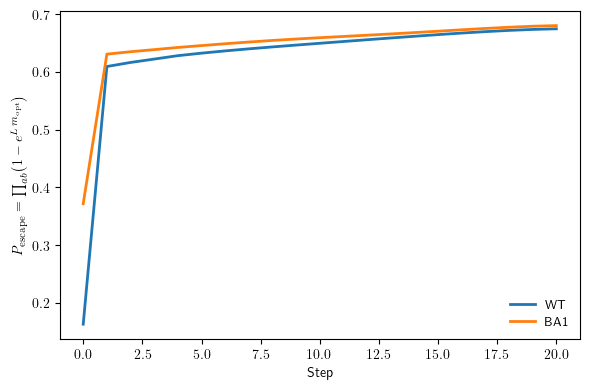

In [6]:
# --- config ---
L = 178.0  # keep consistent with your earlier code

per_condition_series = {}  # condition -> 1D array over steps
x_steps = None
SELECTED_CONDITIONS=['WT', 'BA1']
for i, condition in enumerate(labels):
    if condition not in SELECTED_CONDITIONS:
        continue

    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    Pesc = 1.0 - np.exp(L * mopt)                                              # [steps, n_abs]
    Pesc = np.clip(Pesc, 1e-12, 1.0)                                           # numeric safety

    # product over ALL antibodies, per step
    total_prod = np.exp(np.log(Pesc).sum(axis=1)/Pesc.shape[0]) 
    total_prod = np.exp(np.log(Pesc).mean(axis=1)) 

    # total_prod = np.mean(np.exp(np.log(Pesc)), axis=1)                               # [steps]
                              # [steps]
    per_condition_series[condition] = total_prod
    if x_steps is None:
        x_steps = np.arange(len(total_prod))

# --- plot: one axis, lines = conditions ---
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for condition in SELECTED_CONDITIONS:
    if condition in per_condition_series:
        ax.plot(x_steps, per_condition_series[condition], label=condition, linewidth=2)

ax.set_xlabel("Step")
ax.set_ylabel(r"$P_{\mathrm{escape}}=\prod_{ab}\bigl(1-e^{L\,m_{\mathrm{opt}}}\bigr)$")
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(False)
ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()


Text(0.5, 1.0, 'Escape Probability')

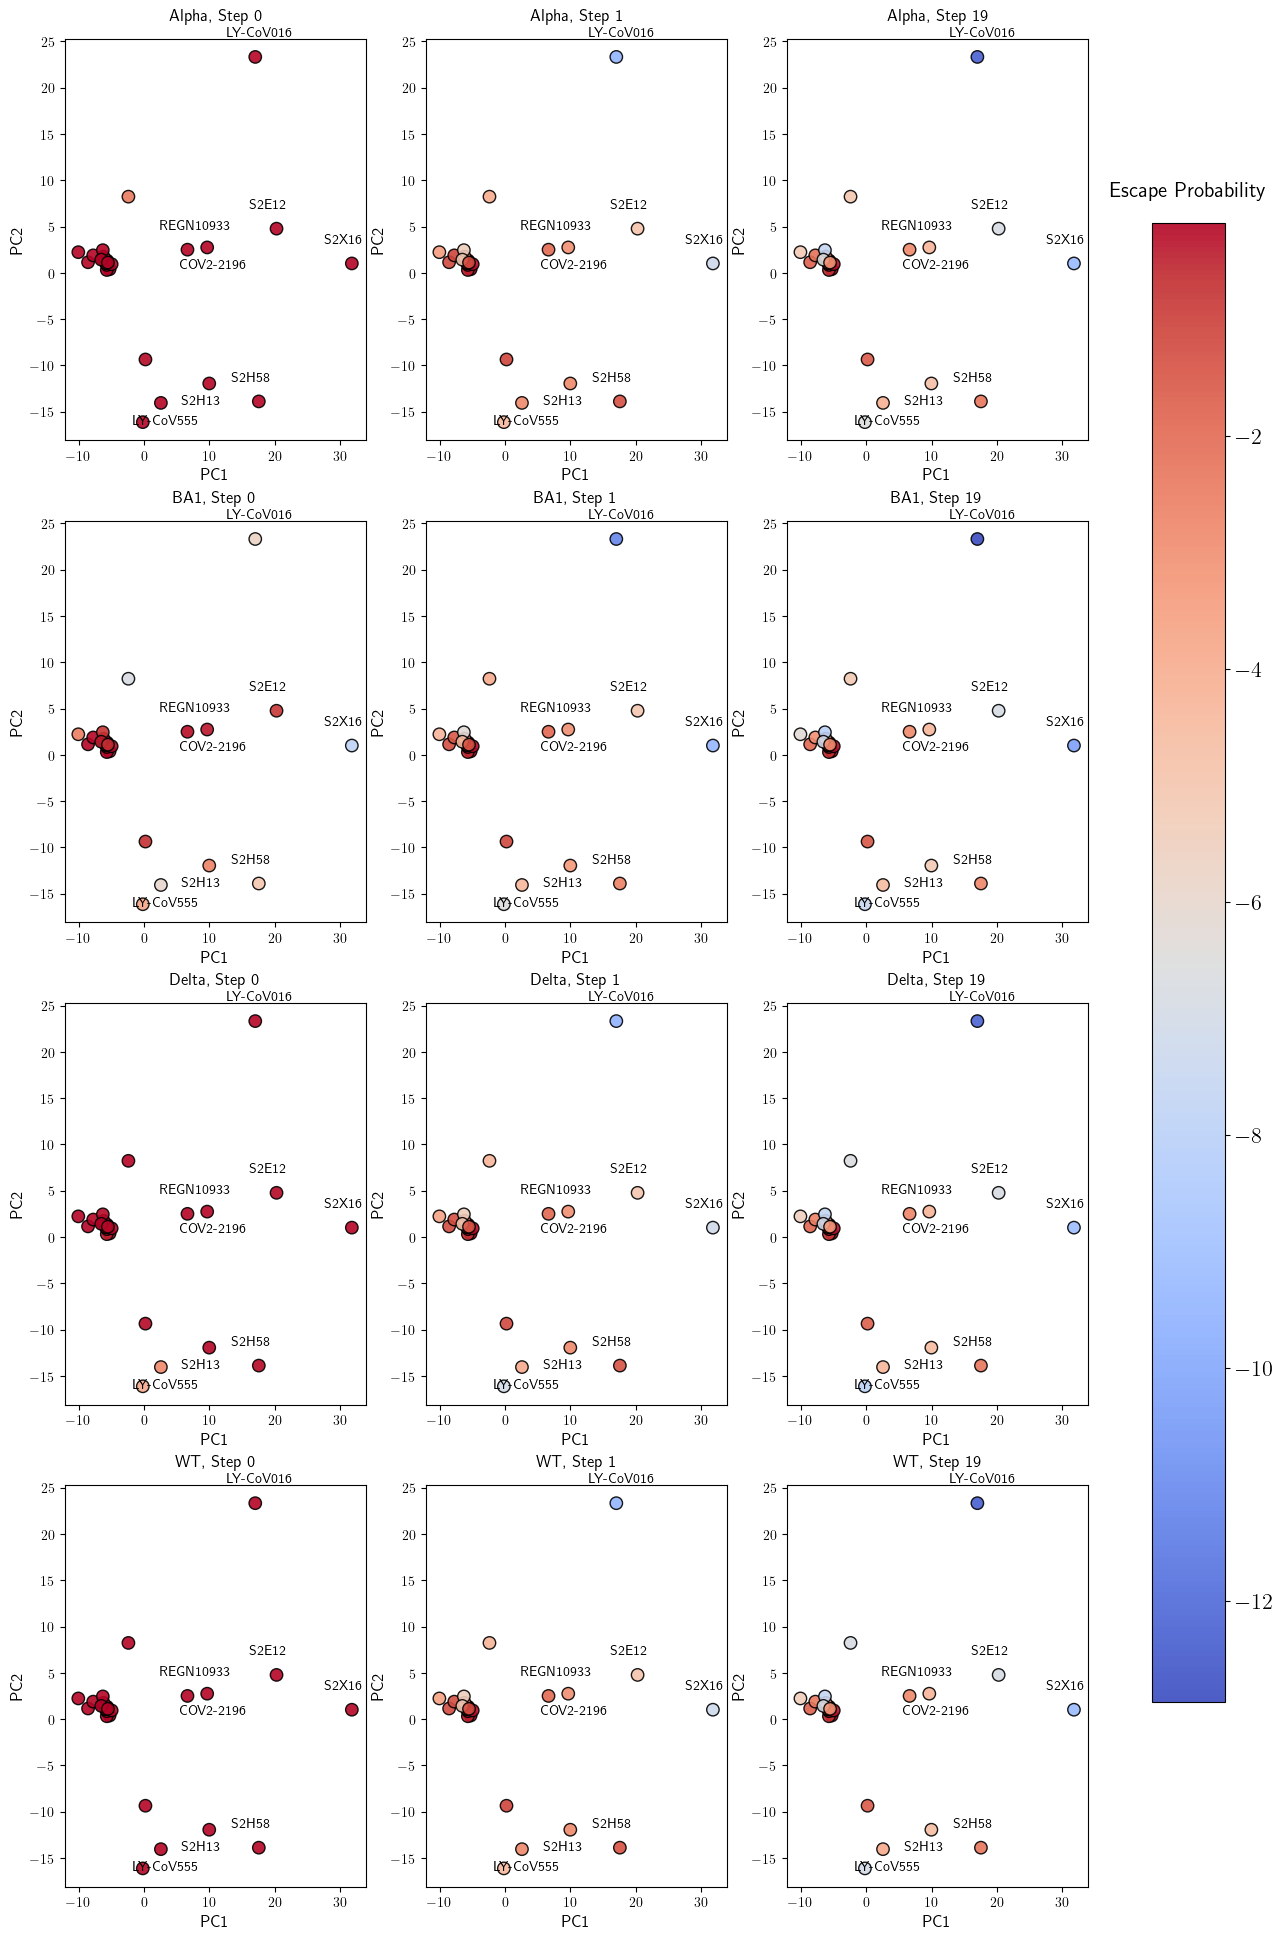

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os
import re
from sklearn.decomposition import PCA
# Select only these conditions:
SELECTED_CONDITIONS = ["WT", "BA1"]

# Setup
dir = '../mean_field_theory/results_scripts/background/'




# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# FIXED PCA of escape vectors (done earlier)
X_escape = np.stack([ESCAPE_VECTORS[ab] for ab in ab_names])
pca = PCA(n_components=2).fit(X_escape)
X_pca = pca.transform(X_escape)  # (n_abs, 2), FIXED

# Plot settings
selected_steps = [0, 1, 19]
n_cols = len(selected_steps)
n_rows = len(labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 6 * n_rows))
axes = axes.reshape(n_rows, n_cols)

# Precompute global min and max
global_min = np.inf
global_max = -np.inf

for i, condition in enumerate(labels):
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :29]
    binding = 178 * mopt

    this_min = binding.min()
    this_max = binding.max()

    global_min = min(global_min, this_min)
    global_max = max(global_max, this_max)

# Then when plotting:
for i, condition in enumerate(labels):
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :29]
    escape = 178 * mopt

    for j, step in enumerate(selected_steps):
        ax = axes[i, j]

        if step >= escape.shape[0]:
            continue

        sc = ax.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=escape[step],
            cmap=plt.cm.coolwarm,
            s=80,
            edgecolor='k',
            alpha=0.9,
            vmin=global_min,
            vmax=global_max
        )

      
        for k, ab in enumerate(ab_names):
            if X_pca[k, 0] < 1 :
                continue
     
            ax.annotate(
                ab,
                (X_pca[k, 0], X_pca[k, 1]),
                textcoords="offset points",
                xytext=(-20, 15*(-1)**(k%5)),  # Alternate y-offset for better visibility
                ha='left',
                fontsize=10,
                color='black',
                #bold
                fontweight='bold',

                # arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
            )
        ax.set_title(f"{condition}, Step {step}", pad=13, fontsize=12)
        ax.set_xlabel("PC1", fontsize=12)
        ax.set_ylabel("PC2", fontsize=12)
        #tick label size
        ax.tick_params(axis='both', which='major', labelsize=10)
# Single global colorbar (consistent across all)
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=0.8)
cbar.ax.tick_params(labelsize=16)
# bar title font size
cbar.ax.set_title("Escape Probability", fontsize=15, pad=20)


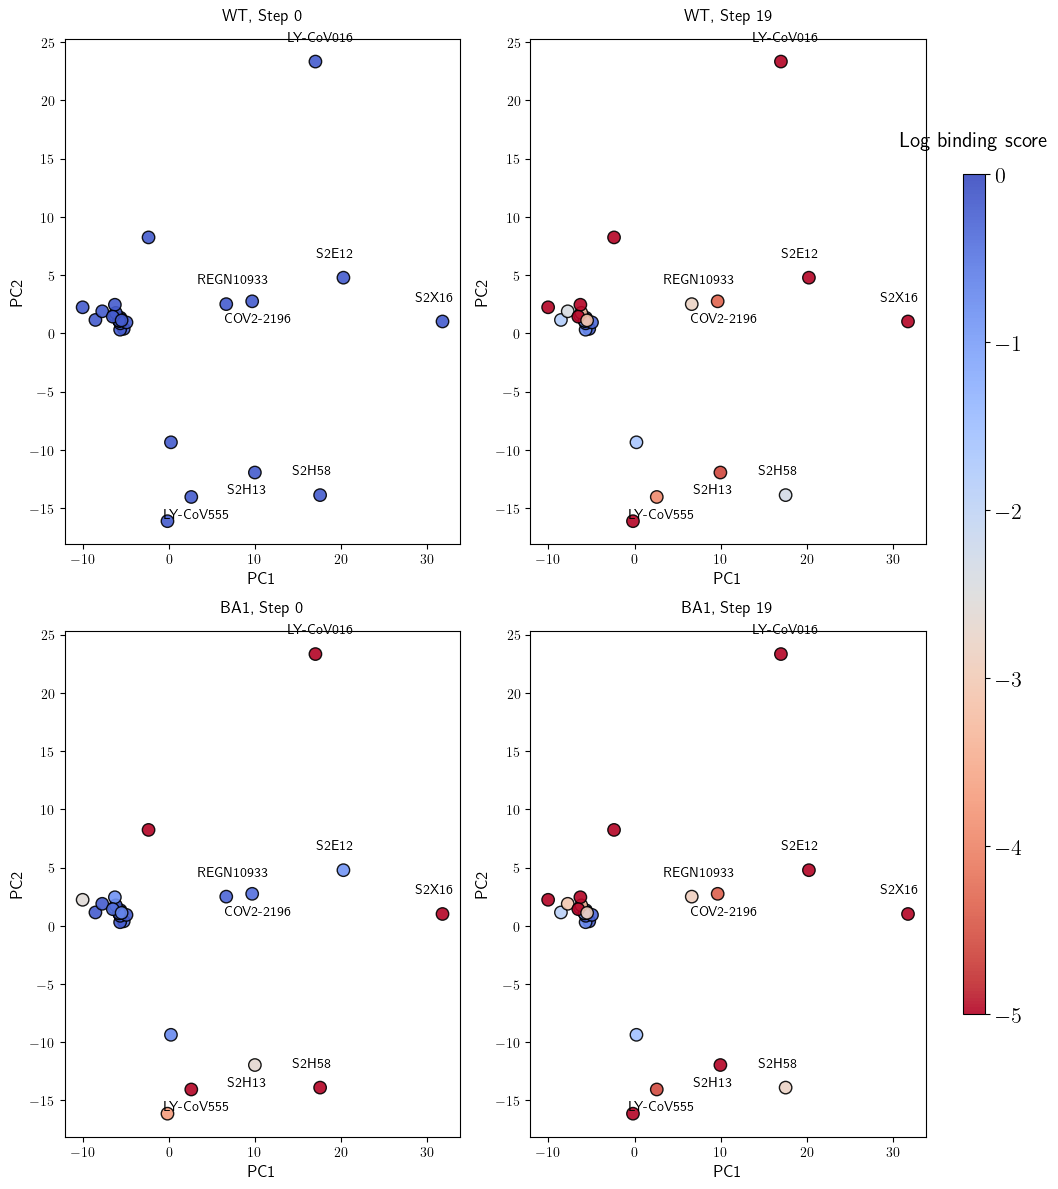

In [8]:
import os, re, math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA

# ---------------- config ----------------
SELECTED_CONDITIONS = ["WT", "BA1"]
DATA_DIR = "../mean_field_theory/results_scripts/background/"
BETA_AB = 1.0
D = 20
selected_steps = [0, 19]
L = 178.0

# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Fixed color mapping: low = red, high = blue. Range [-5, 0].
VMIN, VMAX = -5.0, 0.0
CMAP = plt.cm.coolwarm_r.copy()
CMAP.set_under(CMAP(0.0))  # lowest color instead of black for under
CMAP.set_bad("white")      # NaNs appear white
norm = Normalize(vmin=VMIN, vmax=VMAX)

# ---------------- helpers ----------------
def extract_parameters(path):
    beta_ab_match = re.search(r"beta_ab_(\d+(?:\.\d+)?)", path)
    D_match = re.search(r"D_(\d+)", path)
    parts = path.split("_")
    condition = parts[-1]
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition,
    }

# ---------------- collect folders ----------------
all_dirs = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
paths, labels = [], []
for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB
        and params["D"] == D
        and params["condition"] in SELECTED_CONDITIONS
    ):
        paths.append(d)
        labels.append(params["condition"])

# keep ordering consistent if needed
paths, labels = paths[::-1], labels[::-1]

# ---------------- PCA of escape vectors ----------------
# ab_names and ESCAPE_VECTORS must exist upstream; define ab_names if missing
try:
    ab_names
except NameError:
    ab_names = list(ESCAPE_VECTORS.keys())

X_escape = np.stack([ESCAPE_VECTORS[ab] for ab in ab_names])
pca = PCA(n_components=2).fit(X_escape)
X_pca = pca.transform(X_escape)

# ---------------- figure ----------------
n_cols = len(selected_steps)
n_rows = len(labels)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

# ---------------- plot ----------------
last_sc = None
for i, condition in enumerate(labels):
    mopt = np.load(os.path.join(DATA_DIR, paths[i], "mopt.npy"))[:, : len(ab_names)]
    vals_all = L * mopt  # quantity to color

    for j, step in enumerate(selected_steps):
        ax = axes[i, j]
        if step >= vals_all.shape[0]:
            ax.axis("off")
            continue

        vals = np.clip(vals_all[step], VMIN, VMAX)  # avoid under/over colors

        last_sc = ax.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=vals,
            cmap=CMAP,
            norm=norm,
            s=80,
            edgecolor="k",
            alpha=0.9,
        )

        # labels
        for k, ab in enumerate(ab_names):
            if X_pca[k, 0] < 1:
                continue
            ax.annotate(
                ab,
                (X_pca[k, 0], X_pca[k, 1]),
                textcoords="offset points",
                xytext=(-20, 15 * (-1) ** (k % 5)),
                ha="left",
                fontsize=10,
                color="black",
                fontweight="bold",
            )

        ax.set_title(f"{condition}, Step {step}", pad=13, fontsize=12)
        ax.set_xlabel("PC1", fontsize=12)
        ax.set_ylabel("PC2", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=10)

# ---------------- colorbar on the right, no overlap ----------------
plt.tight_layout(rect=(0, 0, 0.86, 1))           # leave room on the right
cax = fig.add_axes([0.88, 0.15, 0.02, 0.7])      # [left, bottom, width, height]
cbar = fig.colorbar(last_sc, cax=cax, orientation="vertical")
cbar.set_ticks([-5, -4, -3, -2, -1, 0])
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_title("Log binding score", fontsize=15, pad=20)

plt.show()



# Project

## Gisaid

In [9]:
VOCS=Proteins_utils.load_FASTA("../covid/gisaid/sequences_vocs.fasta", drop_duplicates=False)
VOCS = VOCS[:,BEGIN:-END]
def extract_voc_names_from_fasta(fasta_path):
    """
    Extracts VOC names from a FASTA file.
    Assumes each entry starts with a '>' followed by the VOC name.
    """
    voc_names = []
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                voc_name = line[1:].strip()
                voc_names.append(voc_name)
    return voc_names
# List of VOCs to keep
KEEP = {"BA.5", "XBB", "BQ.1.1", "WT", 'BA1'}

# Extract all VOC names
VOC_NAMES = extract_voc_names_from_fasta("../covid/gisaid/sequences_vocs.fasta")

# Build mask for selected VOCs
mask = [any(name.startswith(k) for k in KEEP) for name in VOC_NAMES]

# Apply mask to names and sequences
VOC_NAMES = [name for name, keep in zip(VOC_NAMES, mask) if keep]
VOCS = VOCS[mask,:]
rbd_dates = pd.read_csv('../covid/gisaid/rbd_dates.csv')
rbd_dates=rbd_dates[rbd_dates['count']>1]
print(rbd_dates.shape)
rbd_dates['q05_date'] = pd.to_datetime(rbd_dates['q05_date'])
seqs=Proteins_utils.load_FASTA('../covid/gisaid/rbd_dates_with_sequence.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])
# get indexes of 'count' >1
indexes = rbd_dates[rbd_dates['count'] > 0].index
rbd_dates = rbd_dates.iloc[indexes]
print("rbd_dates", rbd_dates.shape)
one_hot_seqs = one_hot_seqs[indexes]
one_hot_seqs.shape


(4025, 3)
rbd_dates (4025, 3)


(4025, 3560)

In [10]:
wt_idx  = [i for i, n in enumerate(VOC_NAMES) if str(n).startswith("WT")]
ba1_idx = [i for i, n in enumerate(VOC_NAMES) if str(n).startswith("BA1")]

assert wt_idx and ba1_idx, "WT or BA1 not found in VOC_NAMES"

wt_seq  = VOCS[wt_idx[0], :]   # 1D row for WT
ba1_seq = VOCS[ba1_idx[0], :]  # 1D row for BA1

In [21]:
folder='results_scripts/background/mean_f_free_ab_beta_ab_1_D_20_bg_WT'
# folder='results_scripts/mean_f_free_ab_beta_ab_0.2_D_21_ab_class1_2'
mopt = np.load(f"{folder}/mopt.npy") [:,:29]*L
folder0='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_0._D_20'
mopt0 = np.load(f"{folder0}/mopt.npy") [:,:29]*L
folderba1='results_scripts/background/mean_f_free_ab_beta_ab_1_D_20_bg_BA1'
moptba1 = np.load(f"{folderba1}/mopt.npy") [:,:29]*L
mopt.shape


(21, 29)

In [12]:
ab_names = list(ESCAPE_VECTORS.keys())
L=178
wab = np.zeros((L, 20, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, 20)  # "no bias"
    wab[:, :, idx] = w_ab
#put last dimension first
wab = np.moveaxis(wab, -1, 0)
print("wab shape", wab.shape)
wgamma_flat= wab.reshape(wab.shape[0], -1)

wgamma_flat.shape

wab shape (29, 178, 20)


(29, 3560)

In [13]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


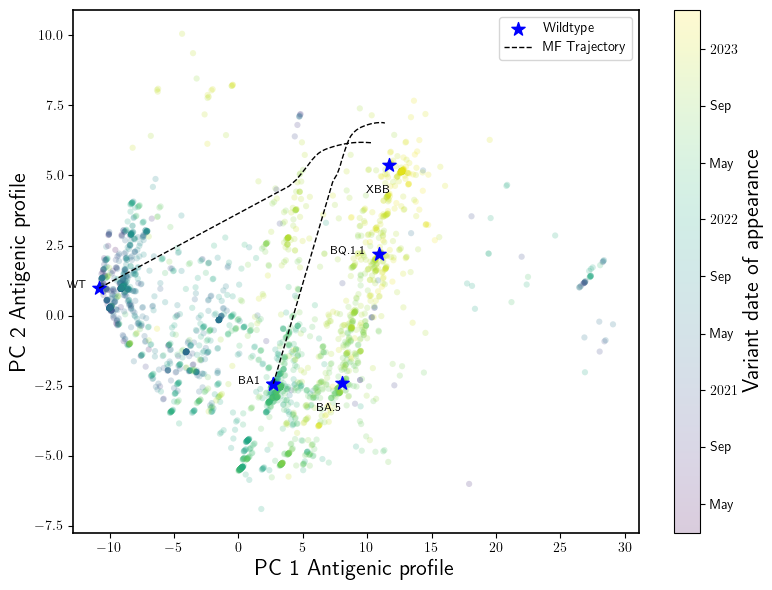

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import numpy as np

# one_hot_seqs: shape (N, D)
# wgamma_flat:  shape (K, D)


# --- usage in your pipeline ---

# 1) project into 50D without BLAS


# …and then continue with your date‐coloring and plotting as before.


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA

def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):
    """
    1) Projects `one_hot_seqs` (N×D) onto each of K axes in `wgamma_flat` (K×D).
    2) Picks the two axes with highest variance.
    3) Plots the resulting 2D embedding, coloring points by `dates_series`.
    
    dates_series should be a pandas Series of length N, dtype datetime64[ns].
    """
    # --- 1) projection without BLAS (optional) or with dot() ---
    projections = project_without_blas(one_hot_seqs, wgamma_flat)



    # 3) get 2D coords

    wt_proj= project_without_blas(np.array([one_hot_encode_concat(wt_seq)]), wgamma_flat)
    wt_proj= project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)

    vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    # --- 2) PCA to reduce to 2D ---

    from sklearn.decomposition import PCA

    # 1) Fit PCA on the full projection data (shape: N × D)
    pca = PCA(n_components=2)    

    X_2d = pca.fit_transform(projections)  # shape: (N, 2)

    vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)


    # 2) Project WT and BA1 onto the same PCA space
    wt_2d = pca.transform(wt_proj)         # shape: (1, 2)



    # 1) make sure you convert your Series to plain Python datetimes
    dates = pd.to_datetime(dates_series)
    np_dates = dates.values.astype("datetime64[us]")

    # 2) turn them into Matplotlib “day‐numbers”

    # Option B: from numpy datetime64[us]
    mdates_num = mdates.date2num(np_dates)


# 3) set up a true Normalize object
    norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())

    # 4) scatter
    # Project mopt onto PCA space
    mopt_2d = pca.transform(mopt)  # shape: (steps, 2)
    moptba1_2d = pca.transform(moptba1)  # shape: (steps, 2)

    # Plot
    fig, ax = plt.subplots(figsize=(8,6))

    # Scatter plot of all points, colored by date
    sc = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=mdates_num,
        cmap='viridis',
        s=20,
        edgecolors='none',
        alpha=0.2,
        
    )

# Add PCA axis labels (optional if you don't have top2 from PCA anymore)
    ax.set_xlabel("PC 1 Antigenic profile", fontsize=16)
    ax.set_ylabel("PC 2 Antigenic profile ", fontsize=16)
    # ax.set_title("Sequences projected onto top-2 PCA axes, colored by appearance date")

    # Add colorbar
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    cbar.ax.yaxis_date()
    cbar.ax.yaxis.set_major_locator(locator)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Variant date of appearance", fontsize=16)

    # Add WT and BA.1 points

    # Add trajectory from mopt
    # ax.scatter(mopt_2d[:, 0], mopt_2d[:, 1], color='black', s=10)  # dots at each step (optional)
    #plto path mopt on top of the scatter
#have 

    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='blue', marker='*', s=100)
        #boldly annotate each point with the corresponding VOC name
        ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
        fontweight='bold', color='black', ha='right')

    #add in legend red star for vocs, point for observed sequences
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')
    ax.plot(mopt_2d[:, 0], mopt_2d[:, 1], color='black', linewidth=1, linestyle='--', label='MF Trajectory')
    ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color='black', linewidth=1, linestyle='--')
    ax.legend()
    #black frame around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()


   
# Example usage:
project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])





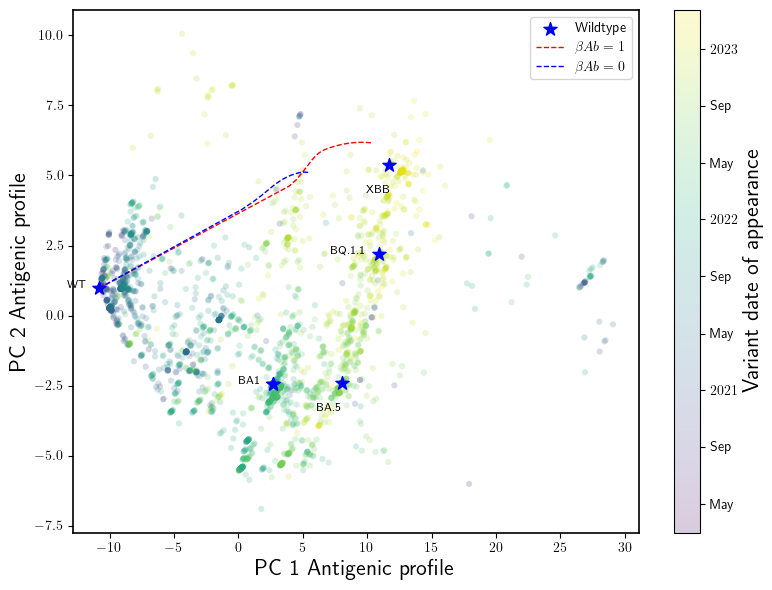

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import numpy as np

# one_hot_seqs: shape (N, D)
# wgamma_flat:  shape (K, D)


# --- usage in your pipeline ---

# 1) project into 50D without BLAS


# …and then continue with your date‐coloring and plotting as before.


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA

def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):
    """
    1) Projects `one_hot_seqs` (N×D) onto each of K axes in `wgamma_flat` (K×D).
    2) Picks the two axes with highest variance.
    3) Plots the resulting 2D embedding, coloring points by `dates_series`.
    
    dates_series should be a pandas Series of length N, dtype datetime64[ns].
    """
    # --- 1) projection without BLAS (optional) or with dot() ---
    projections = project_without_blas(one_hot_seqs, wgamma_flat)



    # 3) get 2D coords

    wt_proj= project_without_blas(np.array([one_hot_encode_concat(wt_seq)]), wgamma_flat)
    wt_proj= project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)

    vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    # --- 2) PCA to reduce to 2D ---

    from sklearn.decomposition import PCA

    # 1) Fit PCA on the full projection data (shape: N × D)
    pca = PCA(n_components=2)    

    X_2d = pca.fit_transform(projections)  # shape: (N, 2)

    vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)


    # 2) Project WT and BA1 onto the same PCA space
    wt_2d = pca.transform(wt_proj)         # shape: (1, 2)



    # 1) make sure you convert your Series to plain Python datetimes
    dates = pd.to_datetime(dates_series)
    np_dates = dates.values.astype("datetime64[us]")

    # 2) turn them into Matplotlib “day‐numbers”

    # Option B: from numpy datetime64[us]
    mdates_num = mdates.date2num(np_dates)


# 3) set up a true Normalize object
    norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())

    # 4) scatter
    # Project mopt onto PCA space
    mopt_2d = pca.transform(mopt)  # shape: (steps, 2)
    moptba1_2d = pca.transform(mopt0)  # shape: (steps, 2)

    # Plot
    fig, ax = plt.subplots(figsize=(8,6))

    # Scatter plot of all points, colored by date
    sc = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=mdates_num,
        cmap='viridis',
        s=20,
        edgecolors='none',
        alpha=0.2,
        
    )

# Add PCA axis labels (optional if you don't have top2 from PCA anymore)
    ax.set_xlabel("PC 1 Antigenic profile", fontsize=16)
    ax.set_ylabel("PC 2 Antigenic profile ", fontsize=16)
    # ax.set_title("Sequences projected onto top-2 PCA axes, colored by appearance date")

    # Add colorbar
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    cbar.ax.yaxis_date()
    cbar.ax.yaxis.set_major_locator(locator)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Variant date of appearance", fontsize=16)

    # Add WT and BA.1 points

    # Add trajectory from mopt
    # ax.scatter(mopt_2d[:, 0], mopt_2d[:, 1], color='black', s=10)  # dots at each step (optional)
    #plto path mopt on top of the scatter
#have 

    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='blue', marker='*', s=100)
        #boldly annotate each point with the corresponding VOC name
        ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
        fontweight='bold', color='black', ha='right')

    #add in legend red star for vocs, point for observed sequences
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')
    ax.plot(mopt_2d[:, 0], mopt_2d[:, 1], color='red', linewidth=1, linestyle='--', label=r'$\beta{Ab}=1$ ')
    ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color='blue', linewidth=1, linestyle='--', label=r'$\beta{Ab}=0$ ')
    ax.legend()
    #black frame around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()


   
# Example usage:
project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])





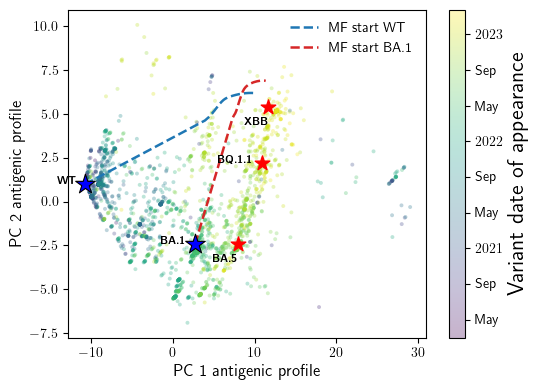

In [15]:
def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):
    """
    Projects N×D sequences onto K antibody axes (wgamma_flat K×D),
    PCA to 2D, colors points by average escape = mean(projection),
    overlays WT/BA1 stars and MF trajectories (mopt, moptba1) on same plot.
    Expects wt_seq, ba1_seq, mopt, moptba1 in scope.
    """
    # 1) projections and average escape
    projections = project_without_blas(one_hot_seqs, wgamma_flat)   # (N,K)
    avg_escape = projections.mean(axis=1)                           # (N,)

    # 2) PCA to 2D
    pca = PCA(n_components=2).fit(projections)
    X_2d = pca.transform(projections)

    # 3) WT and BA1 stars only
    wt_proj  = project_without_blas(np.array([one_hot_encode_concat(wt_seq)]),  wgamma_flat)  # (1,K)
    ba1_proj = project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)  # (1,K)
    wt_2d  = pca.transform(wt_proj)   # (1,2)
    ba1_2d = pca.transform(ba1_proj)  # (1,2)

    vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)

    # 4) MF trajectories (use same PCA space)
    mopt_2d    = pca.transform(mopt)     # (T,2)
    moptba1_2d = pca.transform(moptba1)  # (T,2)

    # 5) plot
    fig, ax = plt.subplots(figsize=(5.5, 4))

       # 1) make sure you convert your Series to plain Python datetimes
    dates = pd.to_datetime(dates_series)
    np_dates = dates.values.astype("datetime64[us]")
    mdates_num = mdates.date2num(np_dates)


# 3) set up a true Normalize object
    norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())
    sc = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=mdates_num,
        cmap='viridis',
        s=8,
        edgecolors='none',
        alpha=0.3,
        
    )

    # WT and BA1 stars
    # for i, (x, y) in enumerate(vocs_2d):
    #     ax.scatter(x, y, color='red', marker='*', s=100)
    #     #boldly annotate each point with the corresponding VOC name
    #     ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
    #     fontweight='bold', color='black', ha='right')

    import matplotlib as mpl
    import matplotlib.patheffects as pe

    use_tex = mpl.rcParams.get("text.usetex", False)

    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='red', marker='*', s=120, zorder=3)

        label = VOC_NAMES[i]
        #replace BA1 with BA.1
        label = label.replace("BA1", "BA.1")
        if use_tex:
            # Escape underscores etc. if needed:
            label_tex = r'\textbf{' + label.replace('_', r'\_') + '}'
            ax.annotate(label_tex, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
                        fontsize=8, color='black', ha='right', zorder=4)
        else:
            ax.annotate(label, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
                        fontsize=8, fontweight='bold', color='black',
                        ha='right', zorder=4)


   
    ax.scatter(wt_2d[0,0],  wt_2d[0,1],  color="blue", marker="*", s=220,
           edgecolors="black", linewidths=0.8, zorder=10)
    ax.scatter(ba1_2d[0,0], ba1_2d[0,1], color="blue", marker="*", s=220,
           edgecolors="black", linewidths=0.8, zorder=10)

    # ax.annotate('WT', (wt_2d[0, 0],  wt_2d[0, 1]+0.5), fontsize=10,#bold 
    #     fontweight='black', color='black', ha='right')
    # ax.annotate('BA.1', (ba1_2d[0, 0], ba1_2d[0, 1]+0.5), fontsize=10,#bold 
    #     fontweight='black', color='black', ha='right')

    # MF trajectories
    ax.plot(mopt_2d[:, 0],    mopt_2d[:, 1],    color="tab:blue", ls="--", lw=1.8, label="MF start WT")
    ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color="tab:red",  ls="--", lw=1.8, label="MF start BA.1")

    # labels and frame
    ax.set_xlabel("PC 1 antigenic profile", fontsize=12)
    ax.set_ylabel("PC 2 antigenic profile", fontsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    # colorbar for average escape
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    cbar.ax.yaxis_date()
    cbar.ax.yaxis.set_major_locator(locator)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Variant date of appearance", fontsize=16)

    ax.legend(frameon=False, fontsize=10, loc="best")
    plt.tight_layout()
    plt.show()

# call:
project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])

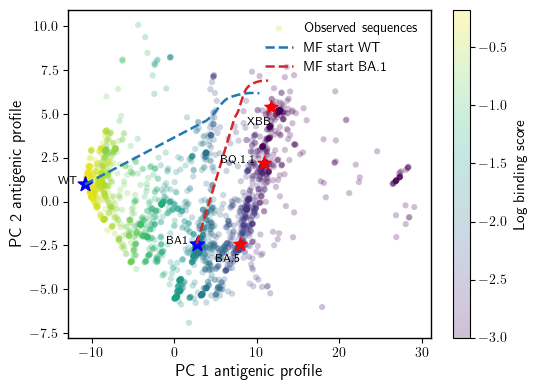

In [16]:
def project_and_plot_2d(one_hot_seqs, wgamma_flat, _unused_dates_series=None):
    """
    Projects N×D sequences onto K antibody axes (wgamma_flat K×D),
    PCA to 2D, colors points by average escape = mean(projection),
    overlays WT/BA1 stars and MF trajectories (mopt, moptba1) on same plot.
    Expects wt_seq, ba1_seq, mopt, moptba1 in scope.
    """
    # 1) projections and average escape
    projections = project_without_blas(one_hot_seqs, wgamma_flat)   # (N,K)
    avg_escape = projections.mean(axis=1)                           # (N,)

    # 2) PCA to 2D
    pca = PCA(n_components=2).fit(projections)
    X_2d = pca.transform(projections)

    # 3) WT and BA1 stars only
    wt_proj  = project_without_blas(np.array([one_hot_encode_concat(wt_seq)]),  wgamma_flat)  # (1,K)
    ba1_proj = project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)  # (1,K)
    wt_2d  = pca.transform(wt_proj)   # (1,2)
    ba1_2d = pca.transform(ba1_proj)  # (1,2)

    vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)

    # 4) MF trajectories (use same PCA space)
    mopt_2d    = pca.transform(mopt)     # (T,2)
    moptba1_2d = pca.transform(moptba1)  # (T,2)

    # 5) plot
    fig, ax = plt.subplots(figsize=(5.5, 4))
    norm = Normalize(vmin=-3, vmax=avg_escape.max())
    sc = ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=avg_escape,
        cmap="viridis",
        norm=norm,
        s=20,
        edgecolors="none",
        alpha=0.25,
        label="Observed sequences"
    )

    # WT and BA1 stars
    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='red', marker='*', s=100)
        #boldly annotate each point with the corresponding VOC name
        ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
        fontweight='bold', color='black', ha='right')

    ax.scatter(wt_2d[0, 0],  wt_2d[0, 1],  color="blue", marker="*", s=120)
    ax.scatter(ba1_2d[0, 0], ba1_2d[0, 1], color="blue",  marker="*", s=120)
    # ax.annotate('WT', (wt_2d[0, 0],  wt_2d[0, 1]+0.5), fontsize=10,#bold 
    #     fontweight='black', color='black', ha='right')
    # ax.annotate('BA.1', (ba1_2d[0, 0], ba1_2d[0, 1]+0.5), fontsize=10,#bold 
    #     fontweight='black', color='black', ha='right')

    # MF trajectories
    ax.plot(mopt_2d[:, 0],    mopt_2d[:, 1],    color="tab:blue", ls="--", lw=1.8, label="MF start WT")
    ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color="tab:red",  ls="--", lw=1.8, label="MF start BA.1")

    # labels and frame
    ax.set_xlabel("PC 1 antigenic profile", fontsize=12)
    ax.set_ylabel("PC 2 antigenic profile", fontsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    # colorbar for average escape
    cbar = fig.colorbar(sc, ax=ax, orientation="vertical")
    cbar.set_label("Log binding score", fontsize=11)

    ax.legend(frameon=False, fontsize=10, loc="best")
    plt.tight_layout()
    plt.show()

# call:
project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])